In [3]:
import json

from football_ai.evaluation import ClusterVisualizer
from football_ai.core import get_config

In [ ]:
config = get_config()

In [5]:
TRACKS_PATH = str(config.get_path('paths', 'output', 'tracks_json')) + "/tracker/tracks_m.json"
VIDEO_PATH = str(config.get_path('paths', 'data', 'video_prueba'))

In [6]:
with open(TRACKS_PATH, "r", encoding="utf-8") as f:
    tracks = json.load(f)

In [7]:
cv = ClusterVisualizer(tracks, VIDEO_PATH)

In [8]:
cv.get_cols()

['class_name',
 'frame',
 'tracker_id',
 'x1',
 'y1',
 'w',
 'h',
 'bbox_size',
 'confidence',
 'Real Madrid',
 'Wolfsburgo',
 'L',
 'A',
 'B',
 'team']

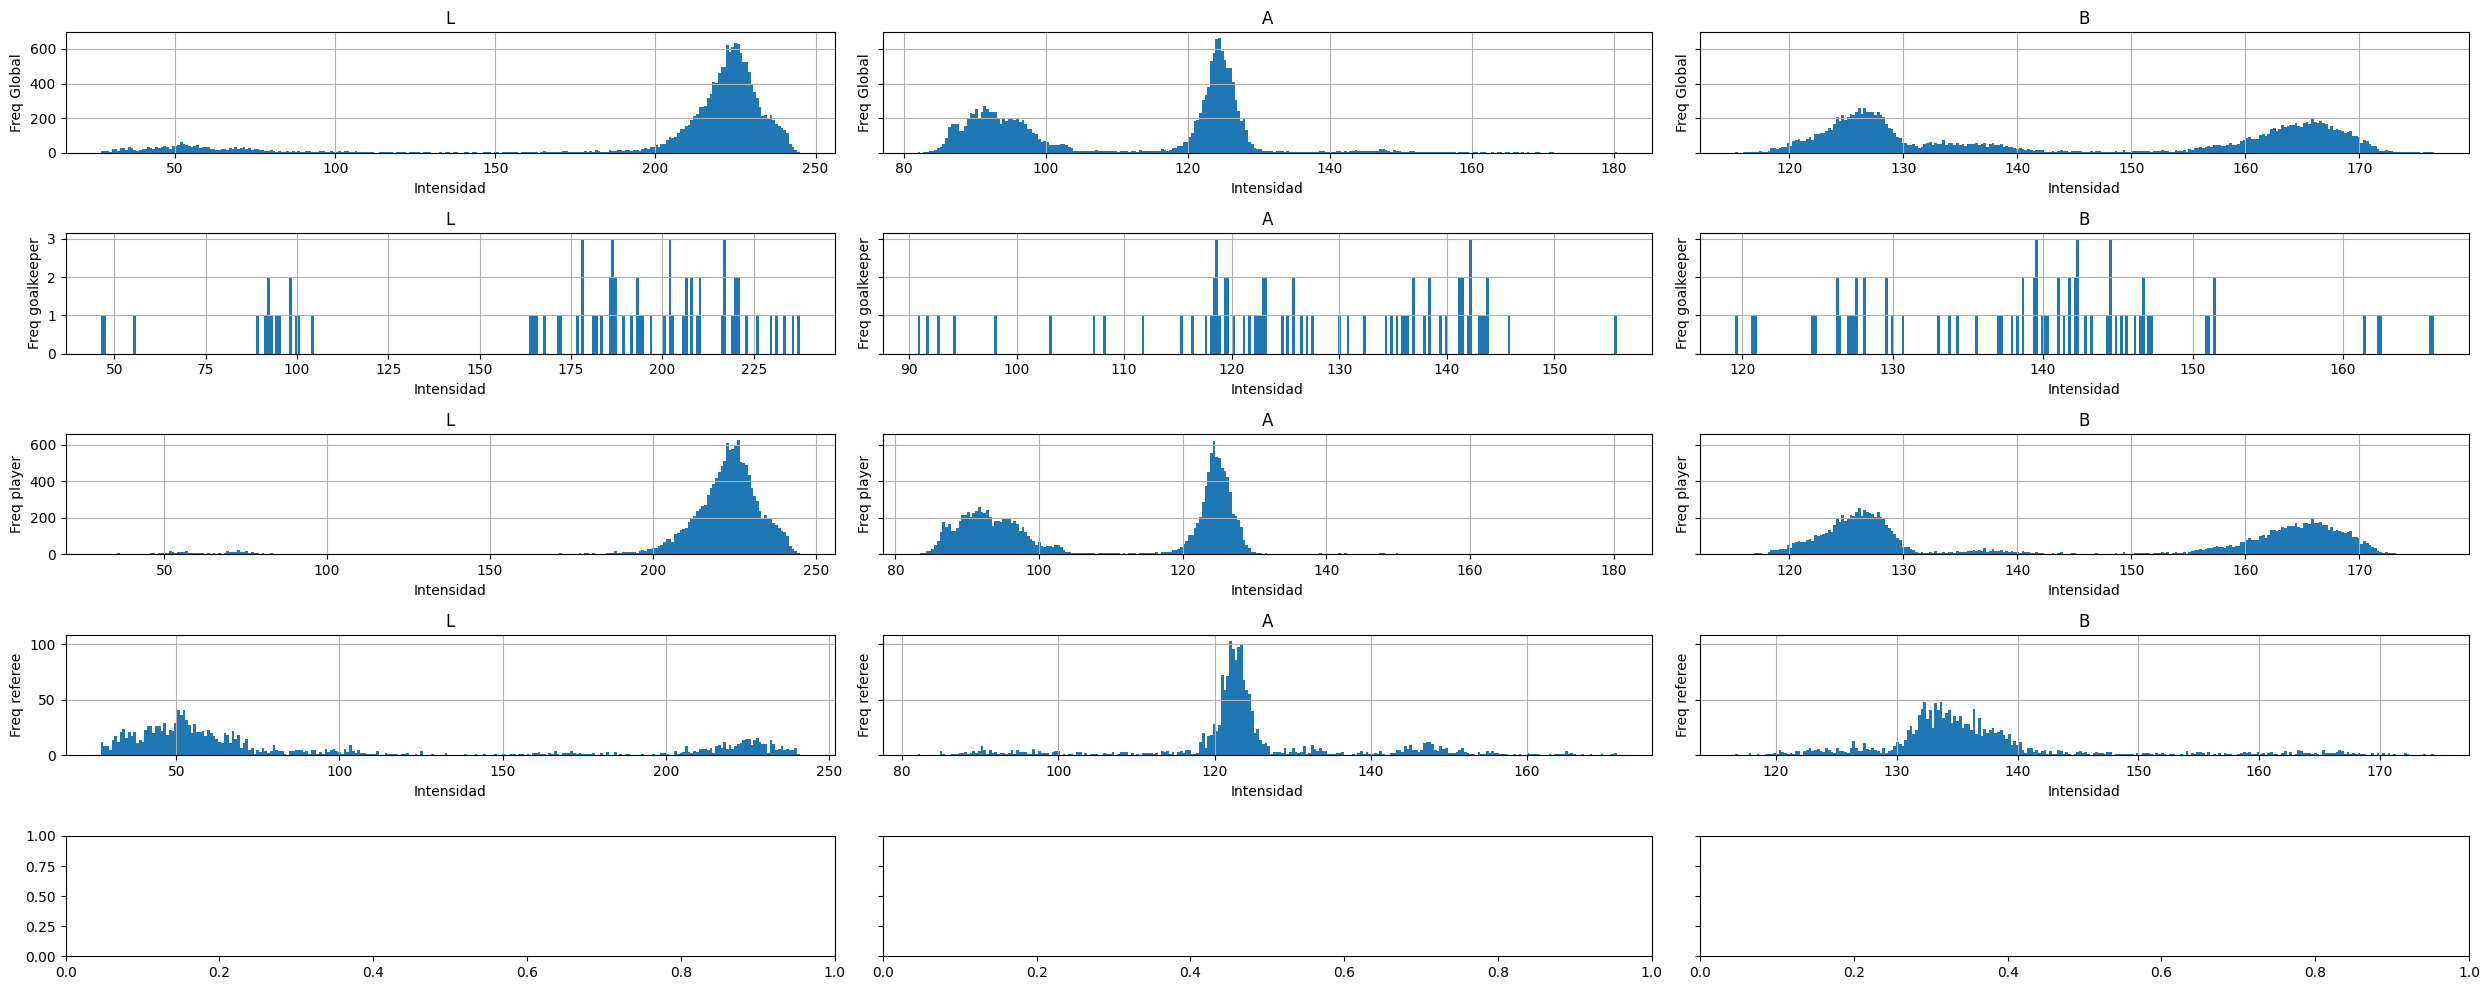

In [9]:
cv.show_hist(["L", "A", "B"], "Intensidad", 10)

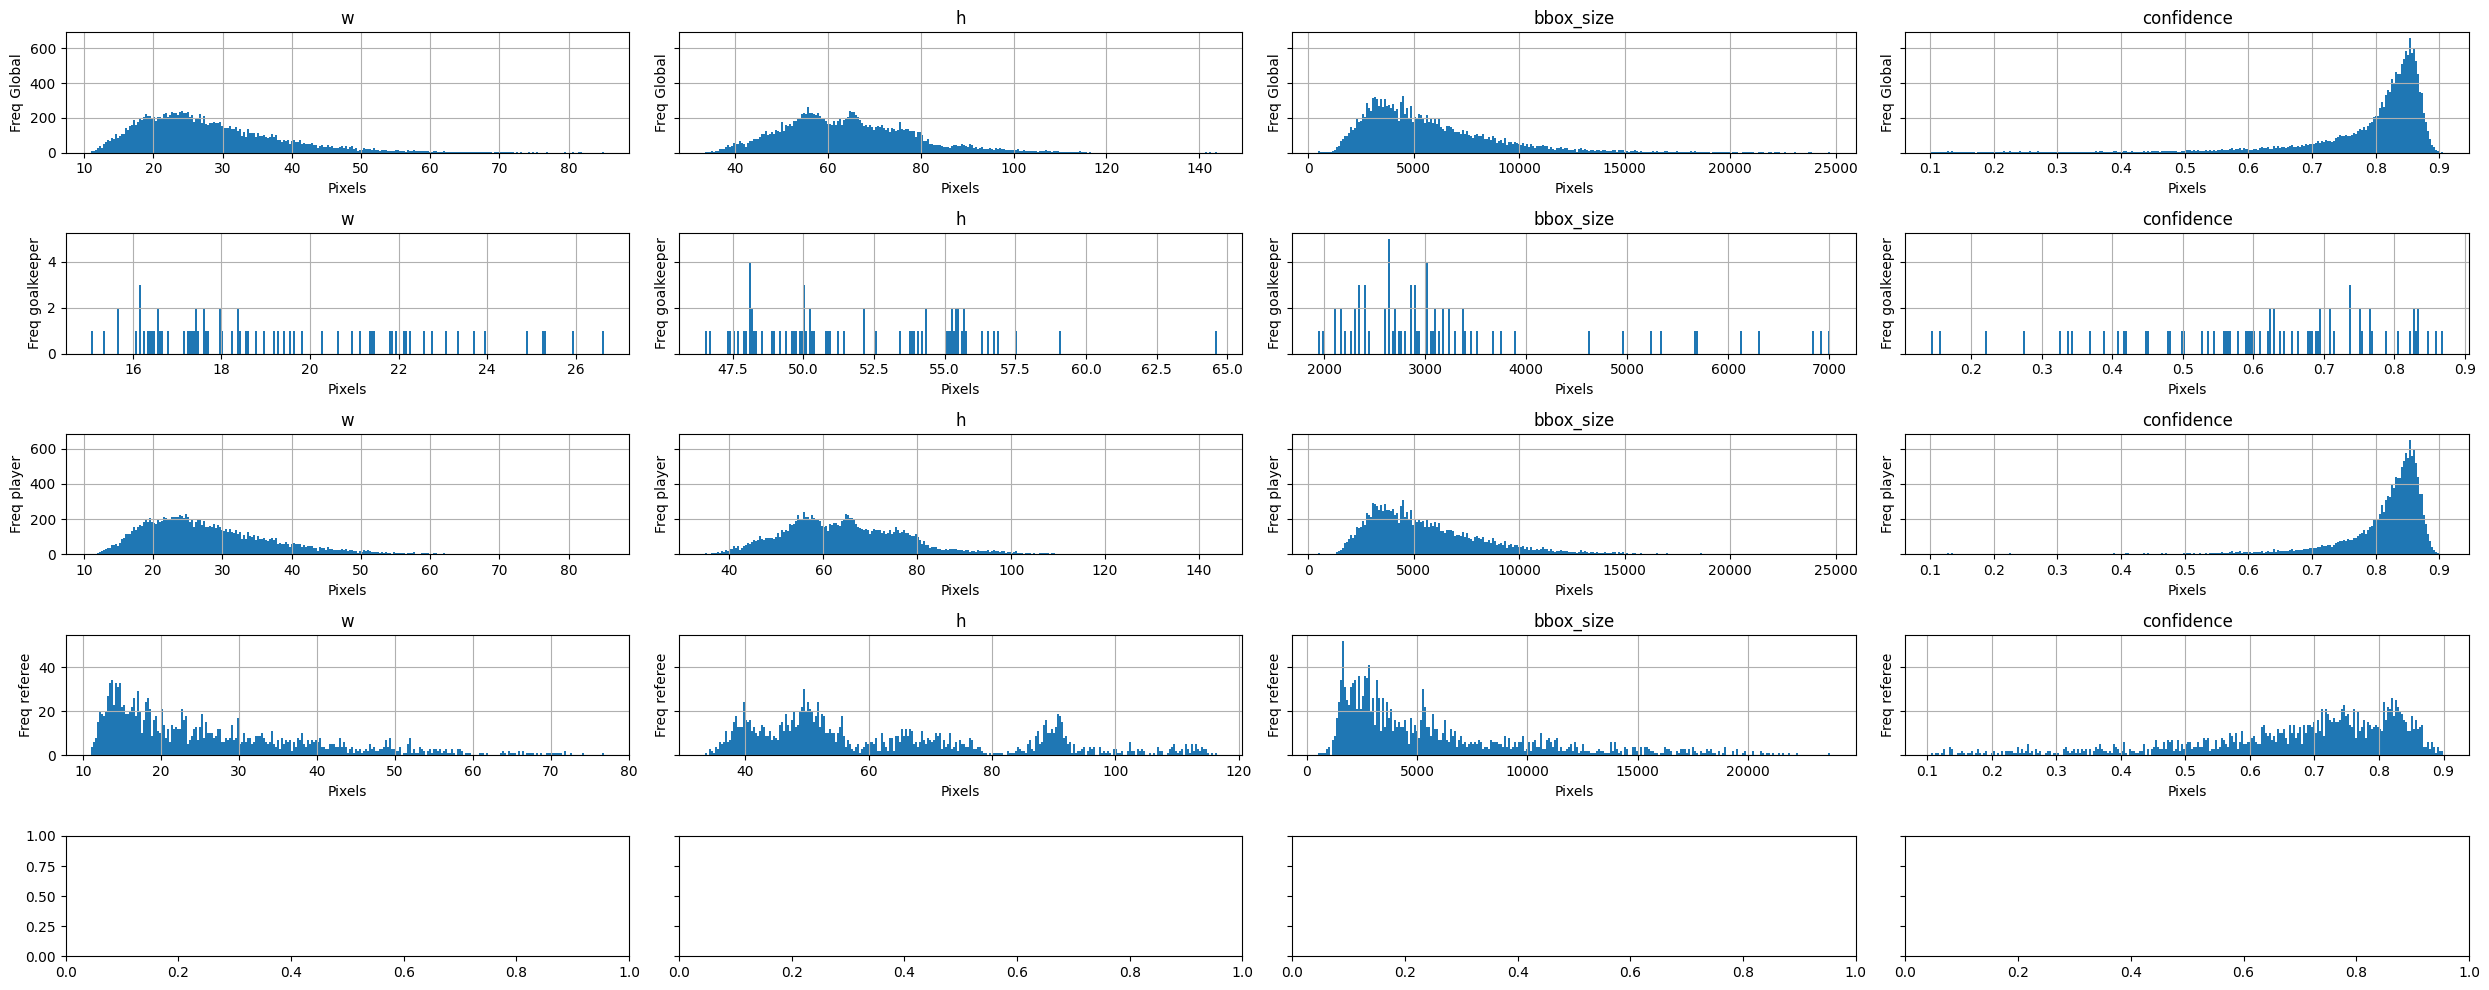

In [10]:
cv.show_hist(["w", "h", "bbox_size", "confidence"], "Pixels", 10)

In [11]:
df = cv.reformed_tracks
df.head()

,class_name,frame,tracker_id,x1,y1,w,h,bbox_size,confidence,Real Madrid,Wolfsburgo,L,A,B,team
0,goalkeeper,139,25,170.404602,463.397552,18.251038,53.801300,5694,0.450092,27.064757,32.747968,217.342020,108.228013,139.560261,Real Madrid
1,goalkeeper,141,25,175.330215,463.543976,16.802094,53.733002,5244,0.535087,52.660731,18.571585,216.711370,91.749271,162.437318,Wolfsburgo
2,goalkeeper,322,25,298.465332,475.410553,23.916962,55.194916,2898,0.336791,53.814745,15.332135,219.263158,92.789474,165.766917,Wolfsburgo
3,goalkeeper,323,25,293.793396,475.242279,21.409332,55.346710,2160,0.419695,18.508187,59.177919,216.860000,132.430000,120.590000,Real Madrid
4,goalkeeper,328,25,268.286957,472.873718,18.366608,56.869629,3078,0.663138,144.460401,148.382289,89.264151,122.207547,138.650943,Real Madrid


In [12]:
df_filtered_1 = df[(df["class_name"]=="player") & (df["A"]<110)].sample(n=20, random_state=42)
df_filtered_2 = df[(df["class_name"]=="player") & (df["A"]>110)].sample(n=20, random_state=42)

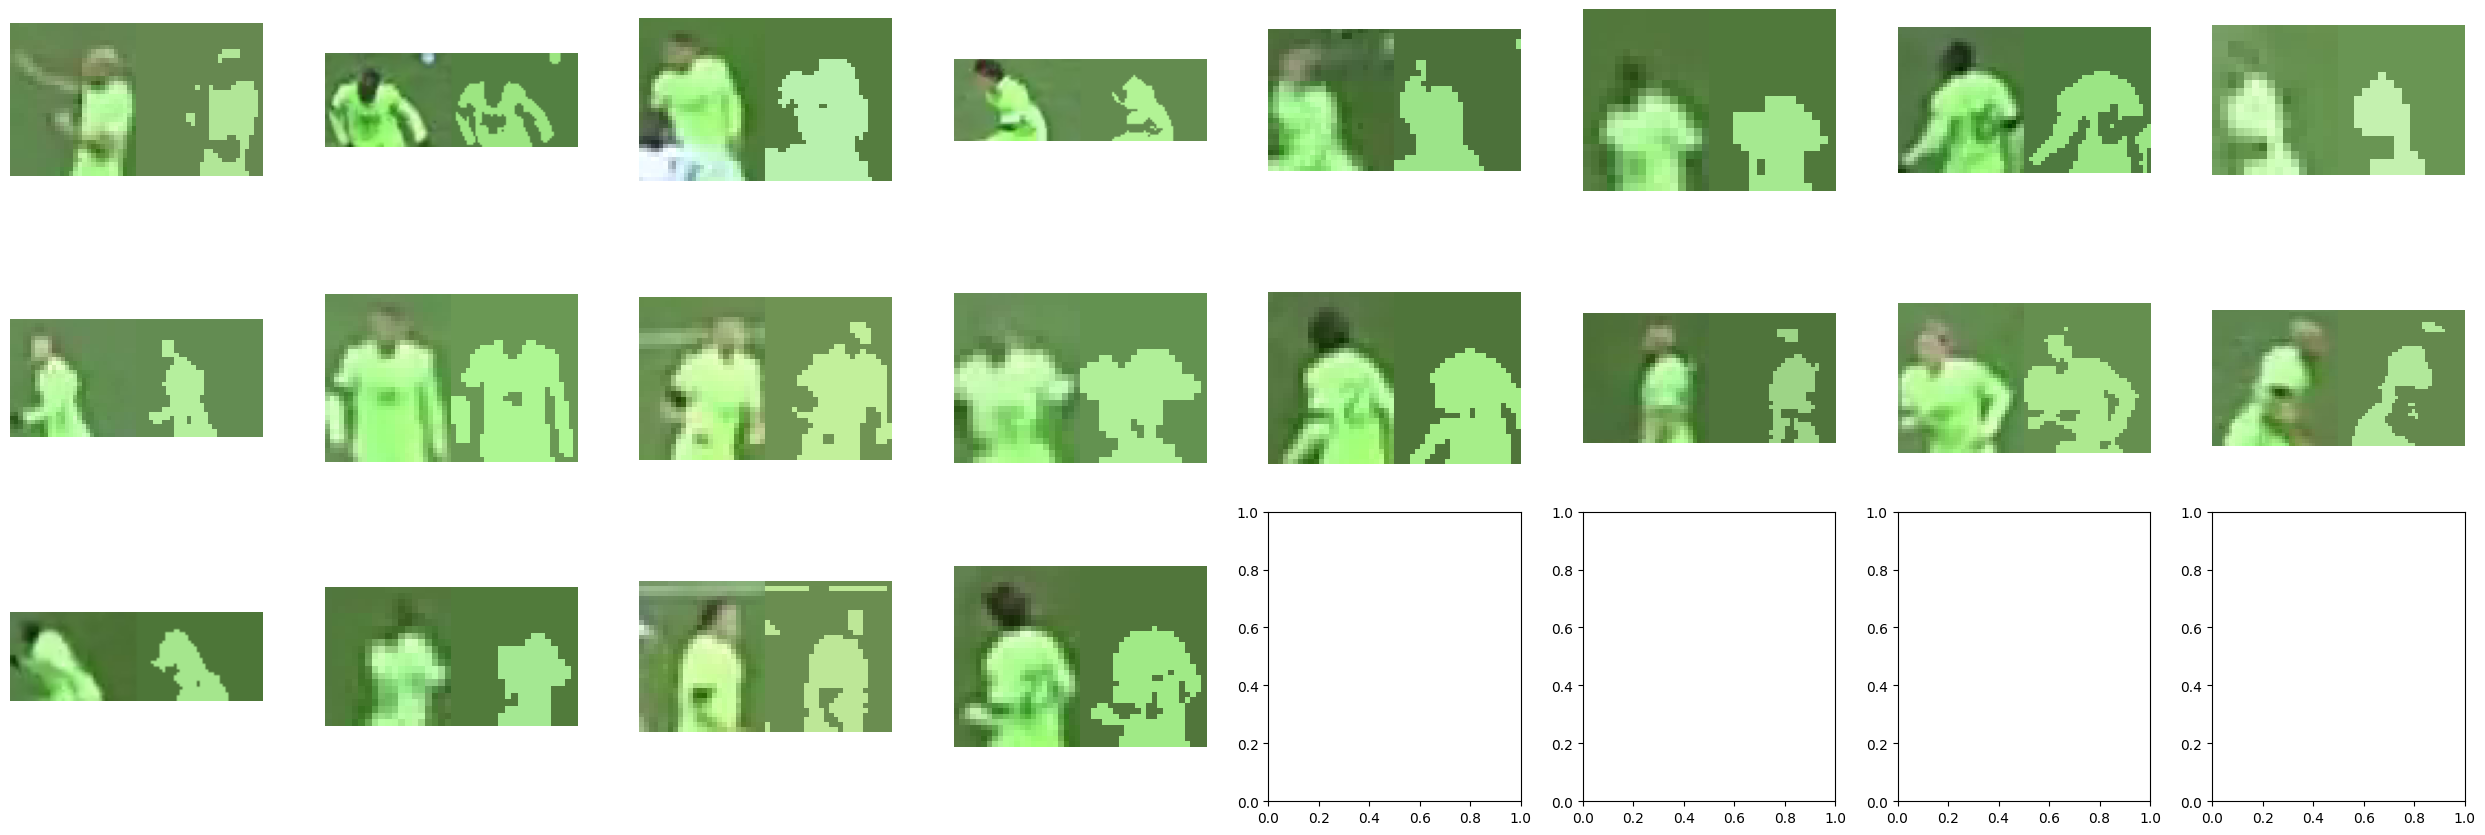

In [13]:
cv.show_clusters(df_filtered_1, ["A"])

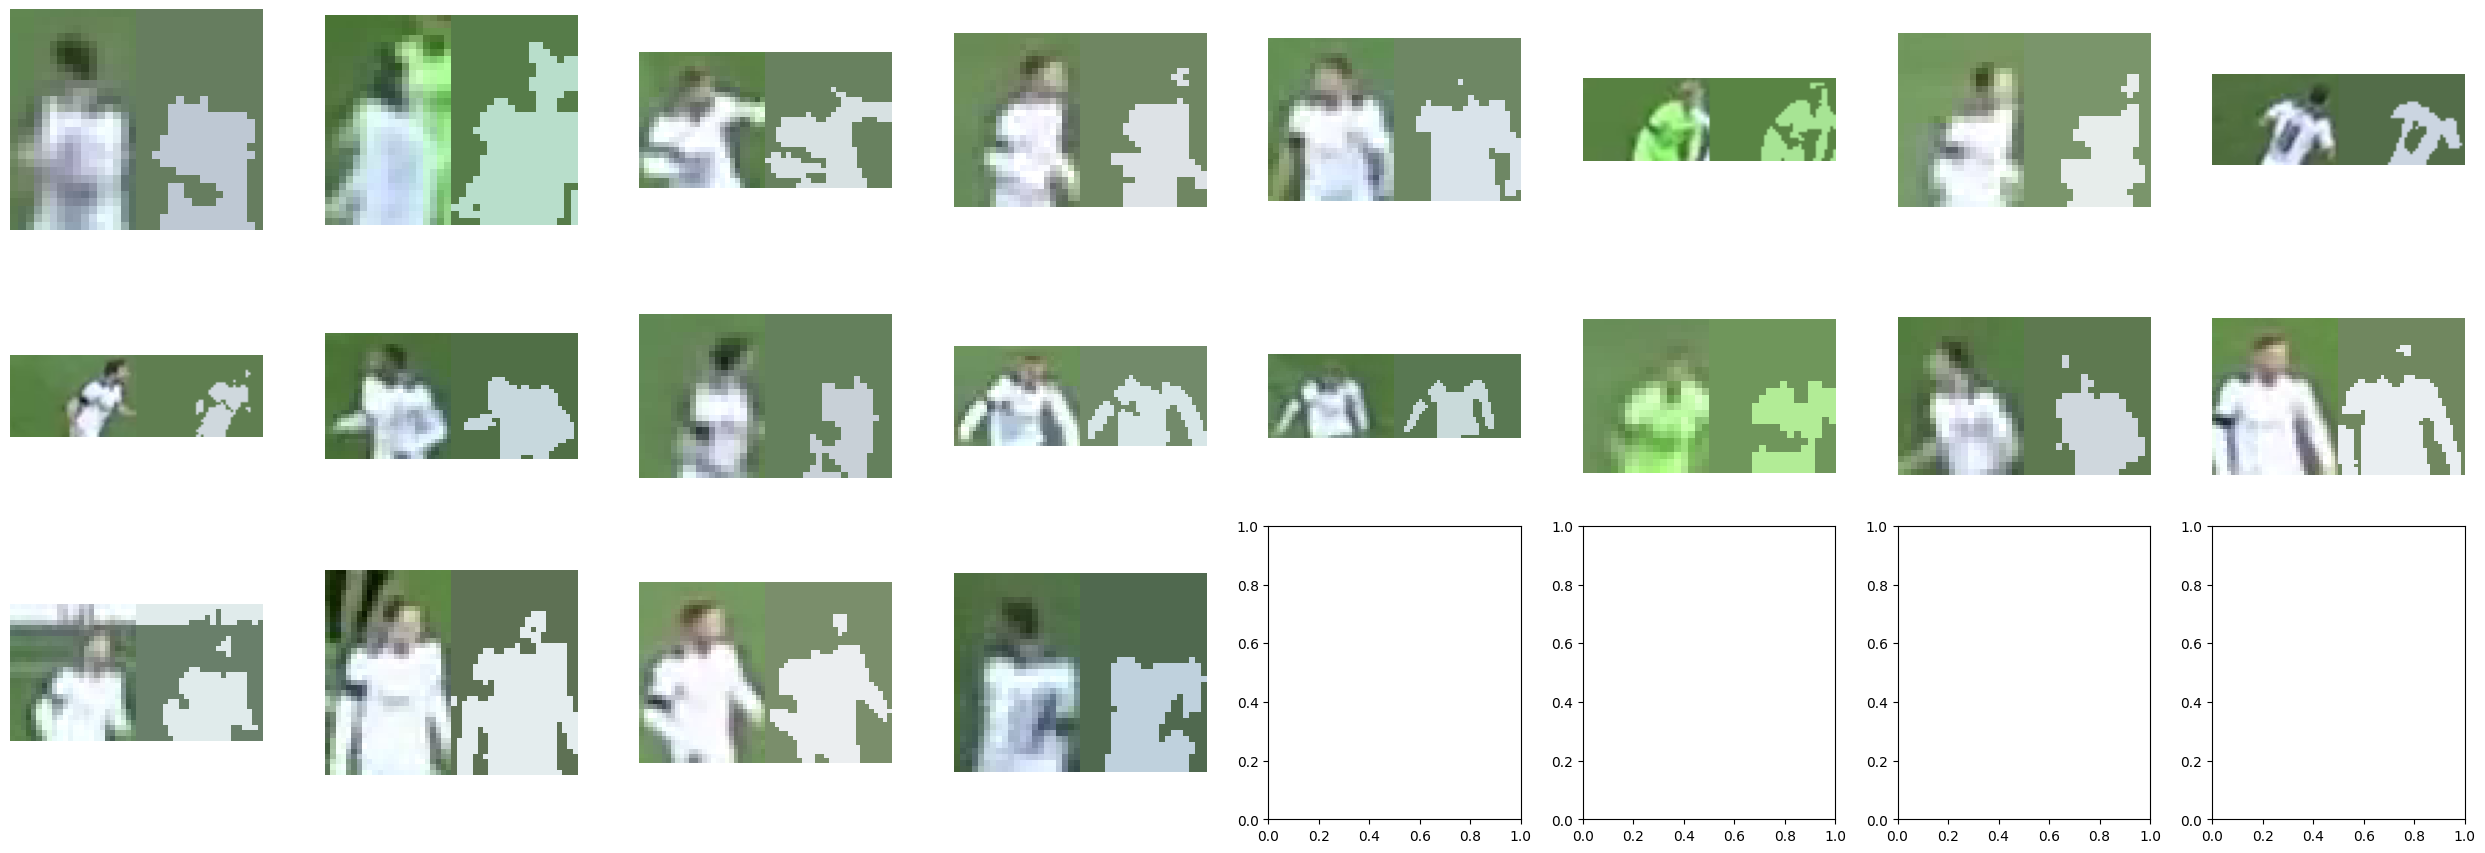

In [14]:
cv.show_clusters(df_filtered_2, ["A"])

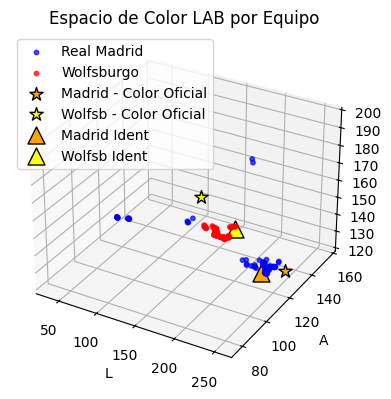

In [15]:
cv.show_clusters_3d("player", 10)

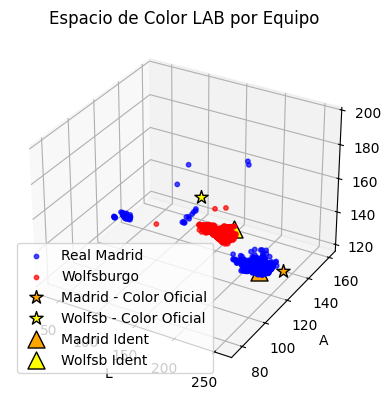

In [16]:
cv.show_clusters_3d("player", 100)

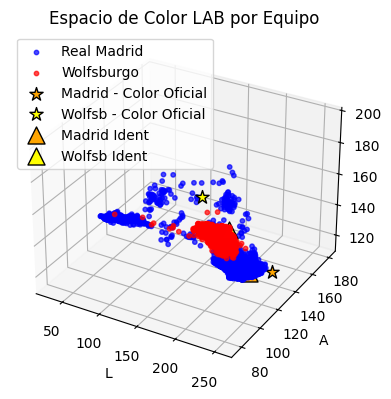

In [17]:
cv.show_clusters_3d("player", 750)

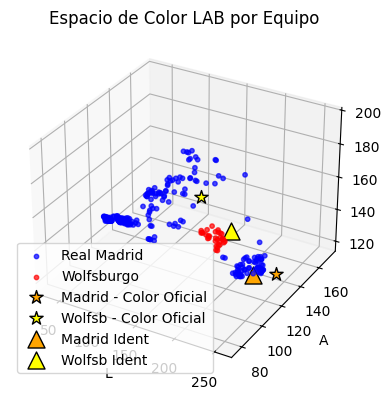

In [18]:
cv.show_clusters_3d("referee", 200)

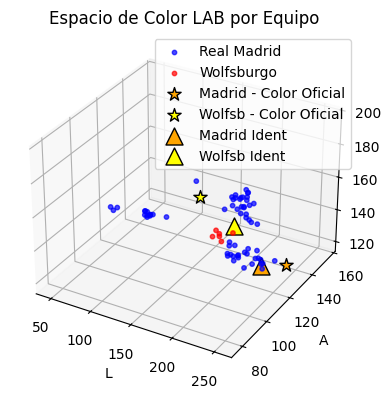

In [19]:
cv.show_clusters_3d("goalkeeper", 750)